# White Noise Drive Qubit Excitation Spectrum

### Author: Daniel Gonçalves Benvenutti - UNICAMP
15 August 2025

Qutip Version: 5.2.0









In [3]:
# to use in google colab
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 62.1 MB/s eta 0:00:00


In [14]:
import qutip as qtp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
#from tqdm.notebook import tqdm

## Simulation Parameters



In [ ]:
# parameters
wq=3*2*np.pi #qubit resonance frequency [GHz.rad]




# operators
sm=qtp.destroy(2)
sx=qtp.sigmax()
sz=qtp.sigmaz()
sy=qtp.sigmay()
n=sm.dag()*sm

# hamiltonian
def H(wq, Ed_t, tlist):# wq[rad.GHz], Ed_t[rad.GHz], tlist[ns]
  # time independant hamiltonian (normalized by wq)
  if Ed_t is None:
    return -0.5*wq*sz/wq
  # time dependant hamiltonian
  # [time independant part, [operator,time dependant operator amplitude]]
  # [qubit, [drive]]
  return qtp.QobjEvo([-0.5*wq*sz/wq,[sx/wq,Ed_t]],tlist=tlist*wq)

# colapse operators normalized by wq
def c_ops(T1, T2): #T1[ns], T2[ns]
  if T2 is None:
    return [np.sqrt(1/T1/wq)*sm]
      # (T2 must be T2<=2T1)
  elif T2>2*T1:
    raise Exception("T2 must be T2<=2T1")
  gamma_phi=1/T2-1/2/T1 #pure dephasing constant
  return [np.sqrt(1/T1/wq)*sm,np.sqrt(gamma_phi/2/wq)*sz]
  #return [np.sqrt(1/T1)*sm,np.sqrt(2*gamma_phi)*n] #same thing for dephasing but in different terms

def simulation(Ed,T1, T2, e="xyz"):
  lenght=2000 #ns
  #pi_pulse=np.pi/Ed #[ns]
  #print(f"pi pulse={pi_pulse:.2e}ns")
  # expected value operators desired (present in sting "e")
  e_ops=[]
  if "x" in e:
    e_ops.append(sx)
  if "y" in e:
    e_ops.append(sy)
  if "z" in e:
    e_ops.append(sz)

  #White noise generator
  tlist=np.linspace(0,lenght,int(lenght*500*wq/2/np.pi))
  drive_data=Ed*np.random.normal(0,1, tlist.shape) #10% Ed amplitude

  #simulation steps
  t=np.linspace(0,lenght,int(lenght*2*wq/2/np.pi)) #ns

  # initial state
  psi0=qtp.basis(2,0)
  res=qtp.mesolve(H(wq,drive_data,tlist),psi0,t*wq,c_ops=c_ops(T1,T2),e_ops=e_ops,options=dict(nsteps=50000))
  return t, res


# Plots

In [ ]:
def plot_fft_tomography(t, expect, graphs="xyz"):
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))  # Adjust figure size as needed
  axes = np.atleast_1d(axes)

  # Calculate the corresponding frequencies
  freq = np.fft.rfftfreq(len(t), d=t[1] - t[0])

  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(freq, np.abs(np.fft.rfft(expect[graphs.index("x")])))
    axes[graphs.index("x")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title(r'Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(freq, np.abs(np.fft.rfft(expect[graphs.index("y")])))
    axes[graphs.index("y")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title(r'Expectation Value of $\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(freq[1:], np.abs(np.fft.rfft(expect[graphs.index("z")])[1:]))
    axes[graphs.index("z")].set_xlabel('Frequency (GHz)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title(r'Expectation Value of $\sigma_z$')
    print(f"DC: {np.fft.rfft(expect[graphs.index("z")])[0]}")


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def plot_tomography(t, expect, graphs="xyz"):
   # string graphs selects plots to make with presence of letters
  fig, axes = plt.subplots(len(graphs), 1, figsize=(8, int(3*len(graphs))))   # Adjust figure size as needed
  axes = np.atleast_1d(axes)
  # Plot sx
  if "x" in graphs:
    axes[graphs.index("x")].plot(t, expect[graphs.index("x")])
    axes[graphs.index("x")].set_xlabel('Time (ns)')
    axes[graphs.index("x")].set_ylabel('<σx>')
    axes[graphs.index("x")].set_title(r'Tomography of the noisy oscillation \n Expectation Value of $\sigma_x$')


  # Plot sy
  if "y" in graphs:
    axes[graphs.index("y")].plot(t, expect[graphs.index("y")])
    axes[graphs.index("y")].set_xlabel('Time (ns)')
    axes[graphs.index("y")].set_ylabel('<σy>')
    axes[graphs.index("y")].set_title(r'Expectation Value of $\sigma_y$')

  # Plot sz
  if "z" in graphs:
    axes[graphs.index("z")].plot(t, expect[graphs.index("z")])
    axes[graphs.index("z")].set_xlabel('Time (ns)')
    axes[graphs.index("z")].set_ylabel('<σz>')
    axes[graphs.index("z")].set_title(r'Expectation Value of $\sigma_z$')


  plt.tight_layout()  # Adjust spacing between subplots
  plt.show()

def diffusive_scale(dt, signal):
    """
    Returns the slope of variance vs lag in log-log scale
    For pure Brownian motion, slope ≈ 1
    """
    n = len(signal)
    lags = np.arange(1, n//2)
    variances = [np.var(signal[lag:] - signal[:-lag]) for lag in lags]
    slope, _ = np.polyfit(np.log(dt*lags), np.log(variances), 1)
    #diffusive scale
    D=slope
    return D

def lorenztian_fit(t, sigz, T2, split =100):
    # Calculate the corresponding frequencies
  dt=t[1]-t[0]
  freq = np.fft.rfftfreq(len(t), d=dt)

  start=1 # remove DC
  split=100
  # FFT of sigz betweeen start and split
  X=np.abs(np.fft.rfft(sigz))[start:split]
  freq_subset = freq[start:split]

  # Define the zero-centered Lorentzian function
  def lorentzian(f, A, gamma,offset):
    return A / (1 + (f/gamma)**2)+offset

  # Fit the Lorentzian function to the data
  popt, pcov = curve_fit(lorentzian, freq_subset, X,p0=[500,1/T2/np.pi, 10])

  # Get the fitted parameters
  A_fit, gamma_fit, offset_fit = popt

  # Generate the fitted curve
  X_fit = lorentzian(freq_subset, A_fit, gamma_fit, offset_fit)

  # Plot the original data and the fitted curve
  plt.plot(freq_subset, X, label='Original Data')
  plt.plot(freq_subset, X_fit, label=fr'$ T_2 \approx {1/gamma_fit/np.pi:.2f} ns$', color='red')
  plt.xlabel('Frequency (GHz)')
  plt.ylabel('<σz>')
  plt.title(r'Expectation Value of $\sigma_z$ with Lorentzian Fit')
  plt.legend()
  plt.show()

  print(f"Fitted Offset: {offset_fit:.2f}")
  print(f"Fitted Amplitude (S0): {A_fit:.2f}")
  print(f"Fitted T2 {1/gamma_fit/np.pi:.2f} ns")
  print(f"var of increments (volatility): {np.var([j-i for i, j in zip(sigz[:-1], sigz[1:])])}")


# Average conserves random walk like property

In [25]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=1
avgz = 0
e="z"
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2, e=e)
  avgz += res.expect[e.index("z")]/samples

  0%|          | 0/1 [00:00<?, ?it/s]

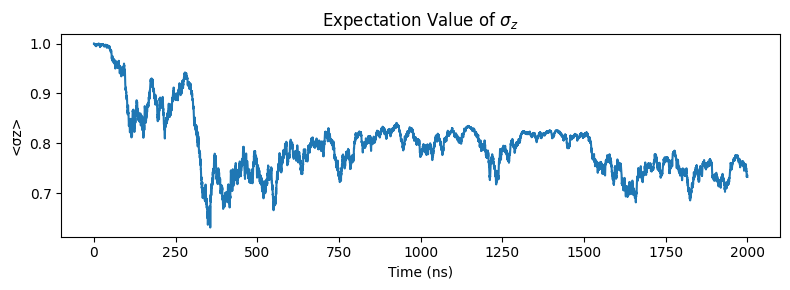

In [26]:
plot_tomography(t, res.expect, graphs="z")

In [27]:
T1=10000 #relaxation time [ns]
T2=1000 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=10
avgz = 0
e="z"
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2, e=e)
  avgz += res.expect[e.index("z")]/samples

  0%|          | 0/10 [00:00<?, ?it/s]

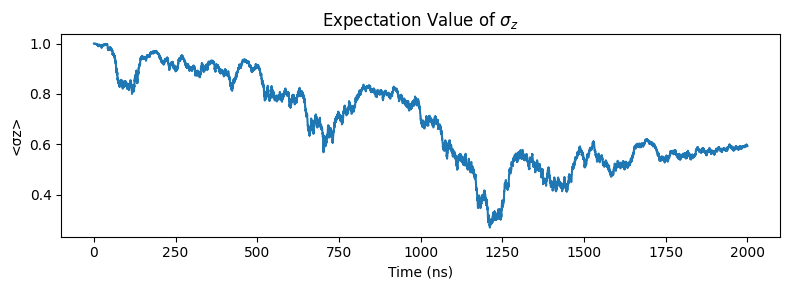

In [28]:
plot_tomography(t, res.expect, graphs="z")

# $T_1=10\mu s , T_2= 200ns$

In [473]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.004*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

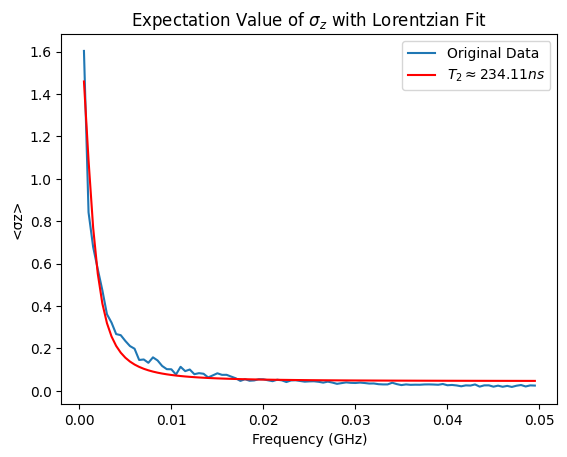

Fitted Offset: 0.05
Fitted Amplitude (S0): 1.60
Fitted T2 234.11 ns
Diffusion intensity (D): 0.5199239392804129
std of increments: 2.5515511201449573e-12


In [474]:
lorenztian_fit(t, avgz, T2)

In [475]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.008*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

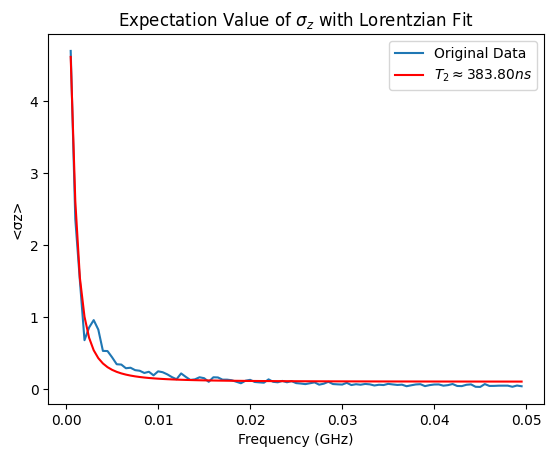

Fitted Offset: 0.10
Fitted Amplitude (S0): 6.15
Fitted T2 383.80 ns
Diffusion intensity (D): 0.412975498846108
std of increments: 2.345252927352666e-11


In [476]:
lorenztian_fit(t, avgz, T2)

In [477]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.016*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

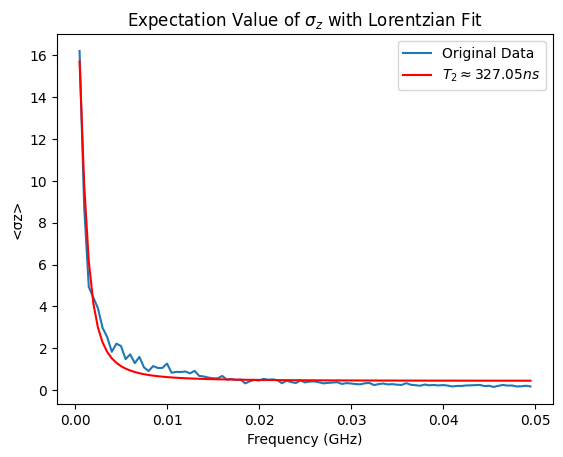

Fitted Offset: 0.45
Fitted Amplitude (S0): 19.27
Fitted T2 327.05 ns
Diffusion intensity (D): 0.5173803353998089
std of increments: 3.656967425755747e-10


In [478]:
lorenztian_fit(t, avgz, T2)

In [479]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.032*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

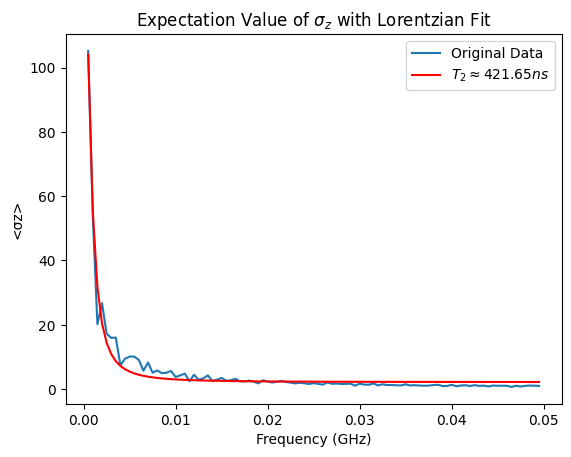

Fitted Offset: 2.18
Fitted Amplitude (S0): 146.58
Fitted T2 421.65 ns
Diffusion intensity (D): 0.5930286249115146
std of increments: 7.32932958514959e-09


In [480]:
lorenztian_fit(t, avgz, T2)

In [481]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.064*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

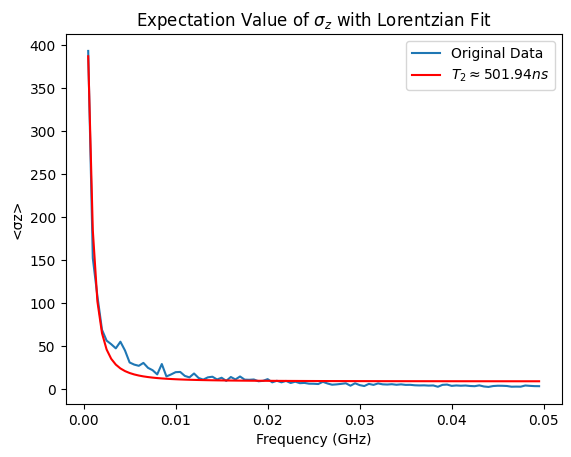

Fitted Offset: 9.37
Fitted Amplitude (S0): 612.25
Fitted T2 501.94 ns
Diffusion intensity (D): 0.9277709471588814
std of increments: 1.0479721658437285e-07


In [482]:
lorenztian_fit(t, avgz, T2)

In [483]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.128*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

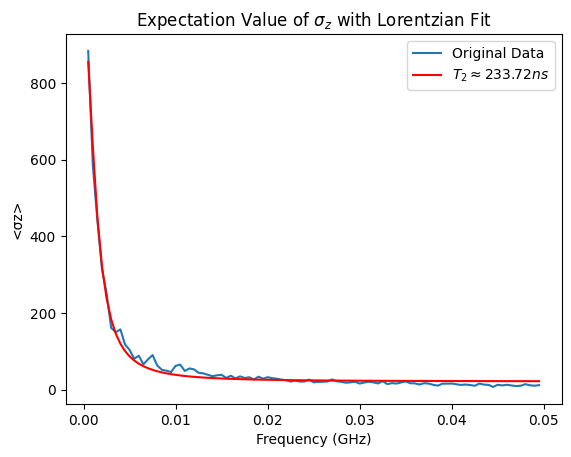

Fitted Offset: 21.45
Fitted Amplitude (S0): 945.99
Fitted T2 233.72 ns
Diffusion intensity (D): 0.9806987578049265
std of increments: 1.0415305250754397e-06


In [484]:
lorenztian_fit(t, avgz, T2)

In [485]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.256*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

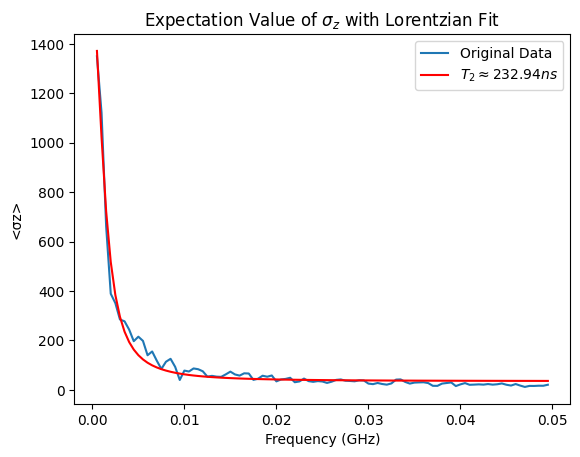

Fitted Offset: 34.79
Fitted Amplitude (S0): 1515.48
Fitted T2 232.94 ns
Diffusion intensity (D): 1.1562063013538288
std of increments: 4.977542325300051e-06


In [486]:
lorenztian_fit(t, avgz, T2)

## Start of regime change

In [9]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.512*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

pi pulse=9.77e-01
pi pulse=9.77e-01
pi pulse=9.77e-01


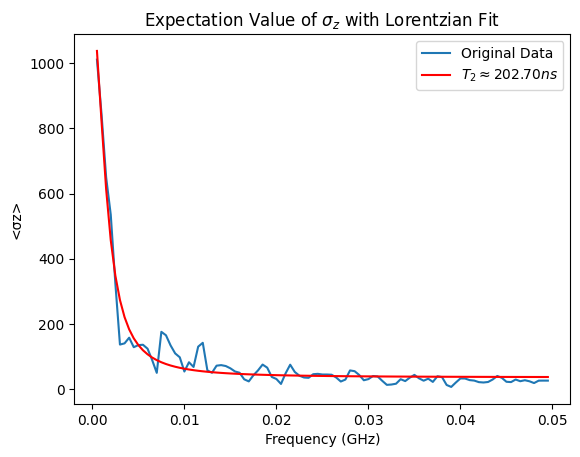

Fitted Offset: 35.59
Fitted Amplitude (S0): 1103.67
Fitted T2 202.70 ns
Diffusion intensity (D): 0.7828551669539305
std of increments (volatility): 1.950039525257512e-05


In [10]:
lorenztian_fit(t, avgz, T2)

In [12]:
T1=10000 #relaxation time [ns]
T2=200 #dephasing time [ns]
Ed=0.8*2*np.pi #driving energy [GHz.rad]
samples=3
avgz = 0
for i in tqdm(range(samples)):
  t, res = simulation(Ed, T1, T2)
  avgz += res.expect[2]/samples

  0%|          | 0/3 [00:00<?, ?it/s]

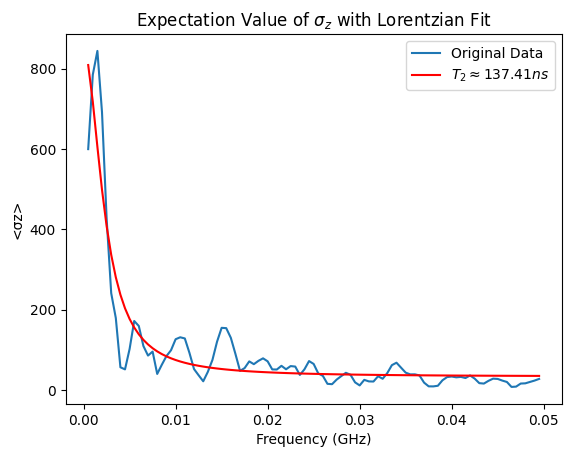

Fitted Offset: 33.60
Fitted Amplitude (S0): 811.91
Fitted T2 137.41 ns
Diffusion intensity (D): 0.5814602016134985
std of increments (volatility): 4.741588506921244e-05


In [13]:
lorenztian_fit(t, avgz, T2)

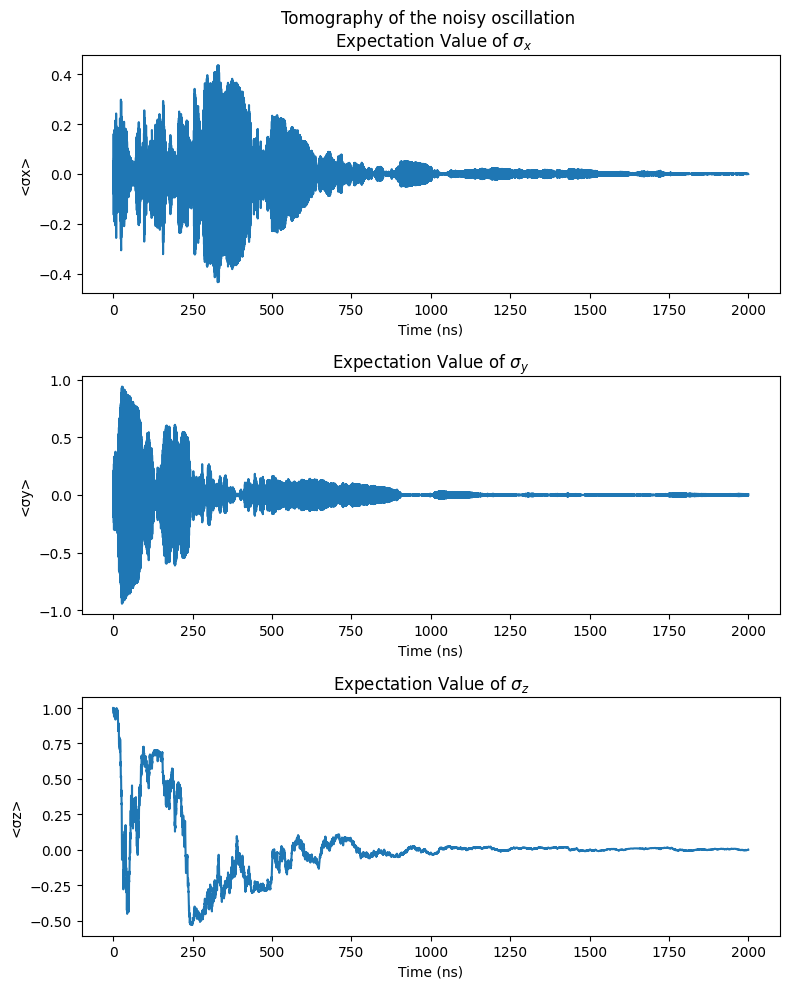

In [14]:
plot_tomography(t, res)

## Final data analysis

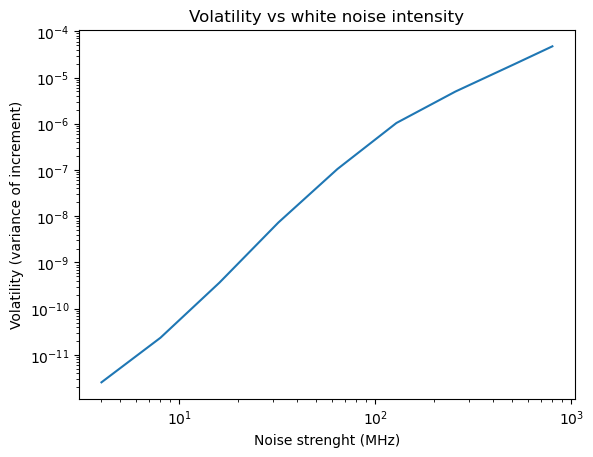

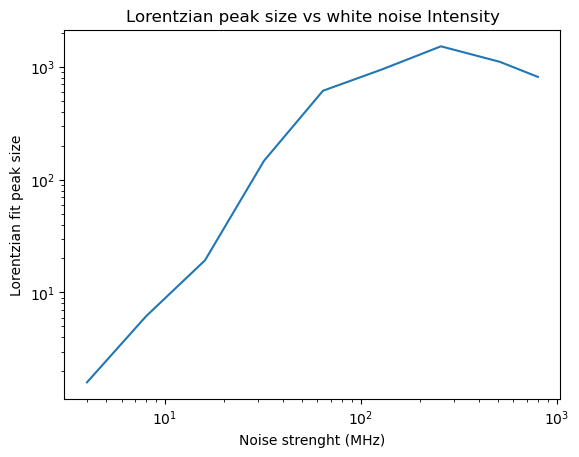

In [9]:
Ed=np.array([0.004,0.008,0.016,0.032,0.064,0.128,0.256,0.512,0.8])
vol=[2.55E-12,2.35E-11,3.66E-10,7.33E-09,1.05E-07,1.04E-06,4.98E-06,1.95E-05,4.74E-05,]
amp=[1.6,6.15,19.27,146.58,612.25,945.99,1515.48,1103.67,811.91,]
plt.loglog(Ed*1000,vol)
plt.xlabel("Noise strenght (MHz)")
plt.ylabel("Volatility (variance of increment)")
plt.title("Volatility vs white noise intensity")

plt.show()
plt.xlabel("Noise strenght (MHz)")
plt.ylabel("Lorentzian fit peak size")
plt.title("Lorentzian peak size vs white noise Intensity")

plt.loglog(Ed*1000,amp)
plt.show()